In [1]:
import lovelyplots
import matplotlib.pyplot as plt
import numpy as np
import scienceplots
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.circuit.library import (
    CXGate,
    RZXGate,
    SwapGate,
    UGate,
    UnitaryGate,
    XXPlusYYGate,
    iSwapGate,
)
from qiskit.circuit.random import random_circuit
from qiskit.quantum_info import Operator, average_gate_fidelity
from qiskit.quantum_info.random import random_unitary
from qiskit.transpiler import (
    InstructionProperties,
    PassManager,
    Target,
    generate_preset_pass_manager,
)
from qiskit.transpiler.passes import Optimize1qGatesDecomposition
from tqdm import tqdm, trange
from weylchamber import c1c2c3

from gulps import logger
from gulps.core.coverage import analyze_coverage, print_coverage_report
from gulps.core.invariants import GateInvariants
from gulps.core.isa import ISAInvariants
from gulps.gulps_decomposer import GulpsDecomposer
from gulps.qiskit_ext.synthesis_pass import GulpsDecompositionPass
from gulps.viz.invariant_viz import render_path
from gulps.viz.polytope_viz import _plot_coverage_set

### Usage as a Decomposer

In [ ]:
# comment out what you don't want or add your own
isa = [
    # (CXGate(), 1.0, "cx"),
    # (CXGate().power(1 / 2), 1 / 2, "sqrt2cx"),
    # (CXGate().power(1 / 6), 1 / 6, "sqrt6cx"),
    # (iSwapGate(), 1.0, "iswap"),
    (iSwapGate().power(1 / 2), 1 / 2, "sqrt2iswap"),
    # (iSwapGate().power(1 / 4), 1 / 4, "sqrt4iswap"),
    (iSwapGate().power(1 / 3), 1 / 3, "sqrt3iswap"),
    # (iSwapGate().power(1 / 6), 1 / 6, "sqrt6iswap"),
    # (fsim(np.pi / 2, np.pi / 6).power(1.0), 1.0, "fsim"),
    # (fsim(np.pi / 2, np.pi / 6).power(1 / 2), 1 / 2, "sqrt2fsim"),
    # (fsim(np.pi / 2, np.pi / 6).power(1 / 3), 1 / 3, "sqrt3fsim"),
    # (SwapGate(), 1.0, "swap"),
    # (SwapGate().power(1 / 2), 1 / 2, "eswap"),
    # (SwapGate().power(1 / 3), 1 / 3, "eswap"),
]
gate_set, costs, names = zip(*isa)
isa = ISAInvariants(gate_set, costs, names, precompute_polytopes=True)
decomposer = GulpsDecomposer(isa=isa)

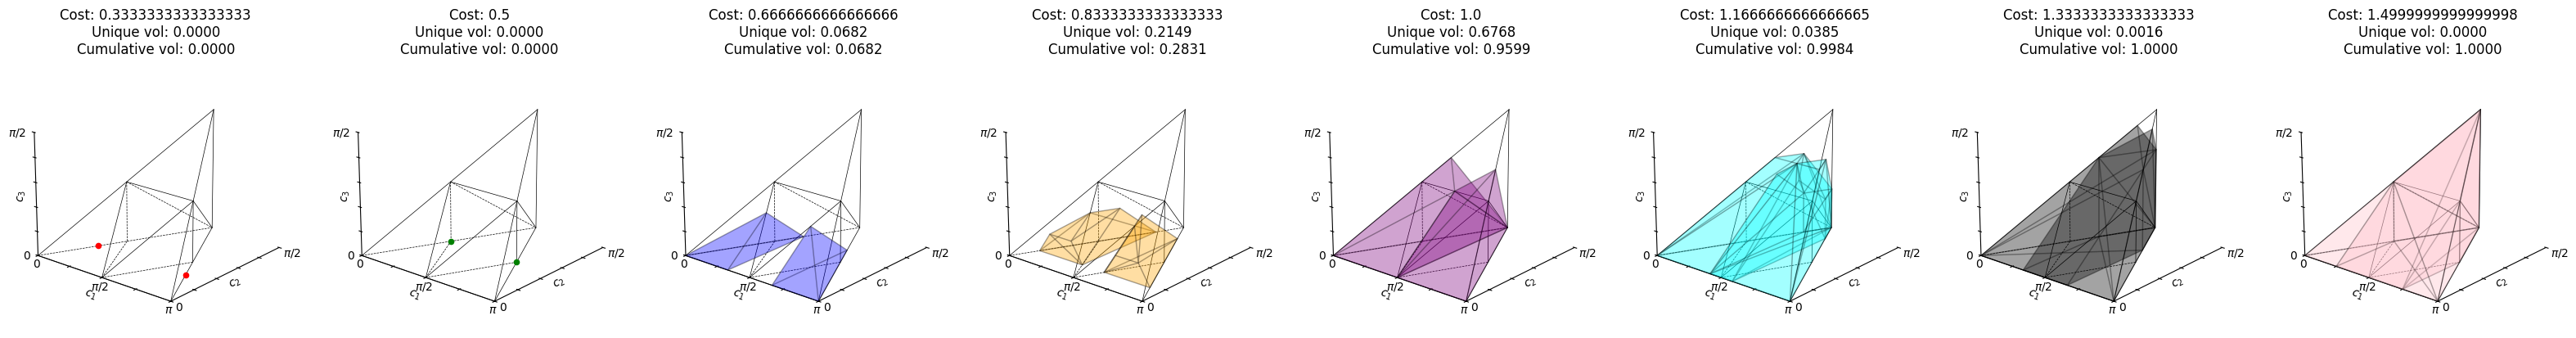

Coverage Set Statistics (Haar-averaged over SU(4))
Expected Cost:  0.948419
  → Average cost per random 2-qubit unitary

Expected Depth: 2.718575
  → Average number of 2-qubit gates


In [3]:
# NOTE if this coverage_set looks odd, it is likely due to setting COST_1Q >0
# this is a good idea for sorting equivalent cost sentences but prioritizing less total segments
# TODO reduce to isa coverage set to avoid this issue, prune more expensive + redundant circuit polytopes
# can use polytope.contains(polytope2) method?
# however, it will split up coverage_set into more pieces due to fine grained cost differences
if hasattr(decomposer.isa, "coverage_set"):
    # Compute all statistics once (efficient: single integral calculation)
    report = analyze_coverage(decomposer.isa.coverage_set)

    # Plot with volume information
    _plot_coverage_set(decomposer.isa.coverage_set, volume_info=report["volume_info"])

    # Print formatted report
    print_coverage_report(report)

In [10]:
logger.setLevel("INFO")
N = 1_000

# Warm-start to trigger JIT compilation (optional)
_ = decomposer(random_unitary(4, seed=0))

fidelities = []
all_timings = []
failures = 0

for idx in trange(N, desc="Decomposing random unitaries"):
    u = random_unitary(4, seed=idx)
    try:
        v = Operator(decomposer(u))
        fid = average_gate_fidelity(u, v)

        if fid < 1 - 1e-8:
            raise ValueError(f"Fidelity too low: {fid:.8f}")

        fidelities.append(fid)
        all_timings.append(decomposer.last_timing)

    except Exception as e:
        print(f"[WARN] Failed on unitary {idx}: {e}")
        failures += 1

# === Fidelity Statistics ===
fidelities = np.array(fidelities)
print(f"\n✔ Completed {len(fidelities)} successful runs (out of {N})")
print(f"  → Failures: {failures}")
print(f"  → Median Fidelity: {np.median(fidelities)}")
print(f"  → Mean Fidelity:   {np.mean(fidelities)}")
print(f"  → Min Fidelity:    {np.min(fidelities)}")

# === Timing Statistics ===
if all_timings:
    phase_names = list(all_timings[0].keys())
    timing_array = np.array([[t[k] for k in phase_names] for t in all_timings])

    print("\nAverage phase durations:")
    for k, mean_time in zip(phase_names, timing_array.mean(axis=0)):
        print(f"  {k:>10}: {mean_time:.4f} s")

    print(f"\n  Total average time: {timing_array.sum(axis=1).mean():.4f} s")
else:
    print("No successful timings collected.")

Decomposing random unitaries:  42%|████▎     | 425/1000 [00:15<00:21, 26.28it/s]

[WARN] Failed on unitary 419: Segment 2 synthesis failed (residual norm=6.54e-09).


Decomposing random unitaries:  53%|█████▎    | 533/1000 [00:19<00:18, 24.79it/s]

[WARN] Failed on unitary 529: Segment 3 synthesis failed (residual norm=1.35e-07).


Decomposing random unitaries: 100%|██████████| 1000/1000 [00:35<00:00, 28.09it/s]


✔ Completed 998 successful runs (out of 1000)
  → Failures: 2
  → Median Fidelity: 0.9999999999999822
  → Mean Fidelity:   0.999999999996783
  → Min Fidelity:    0.9999999997146085

Average phase durations:
  lp_sentence: 0.0026 s
    segments: 0.0307 s

  Total average time: 0.0333 s


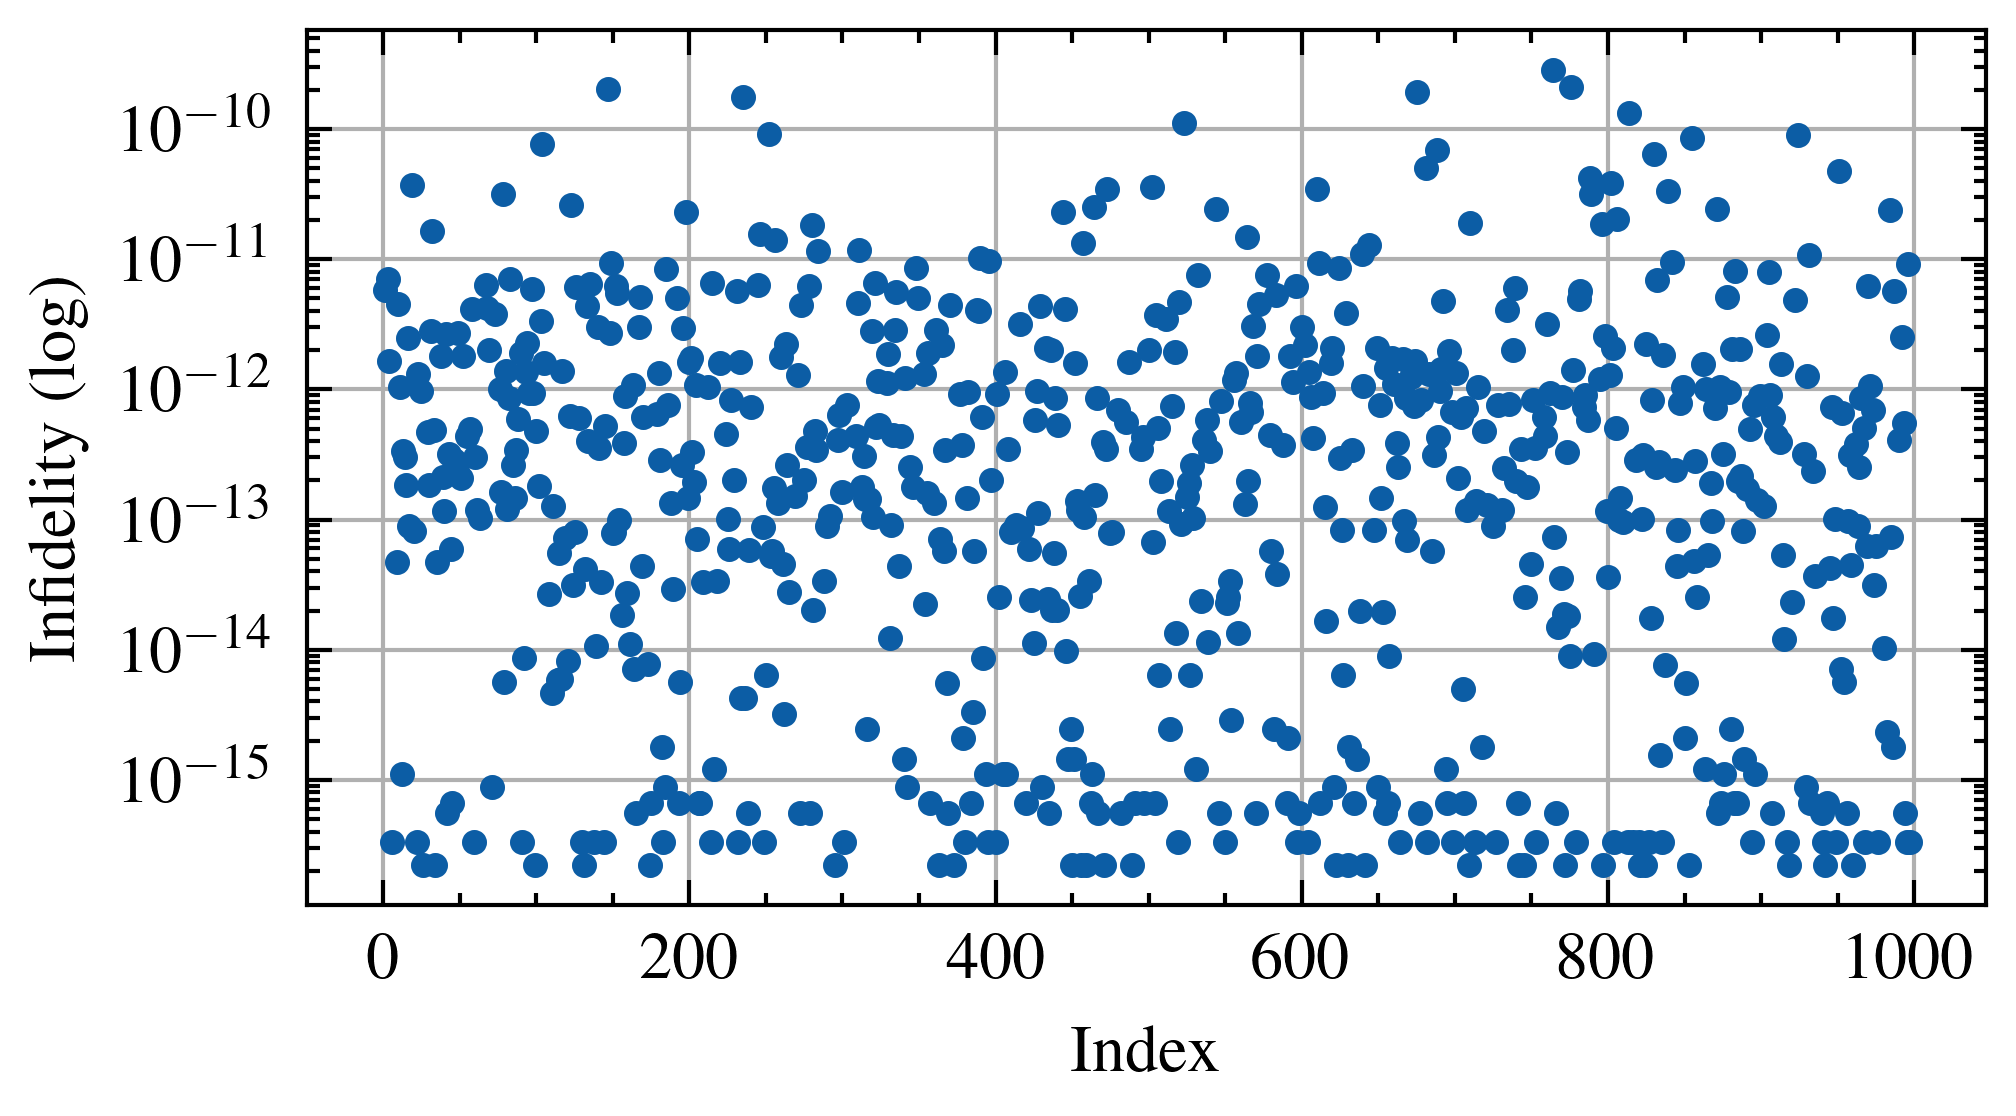

In [11]:
# make a plot for the fidelities
with plt.style.context(["ieee", "science", "use_mathtext"]):
    fig, ax = plt.subplots(figsize=(3.5, 2))
    ax.plot(1 - fidelities, marker="o", markersize=2, linestyle="None")
    ax.set_xlabel("Index")
    ax.set_ylabel("Infidelity (log)")
    ax.set_yscale("log")
    ax.grid(True)
    plt.tight_layout()
    plt.show()

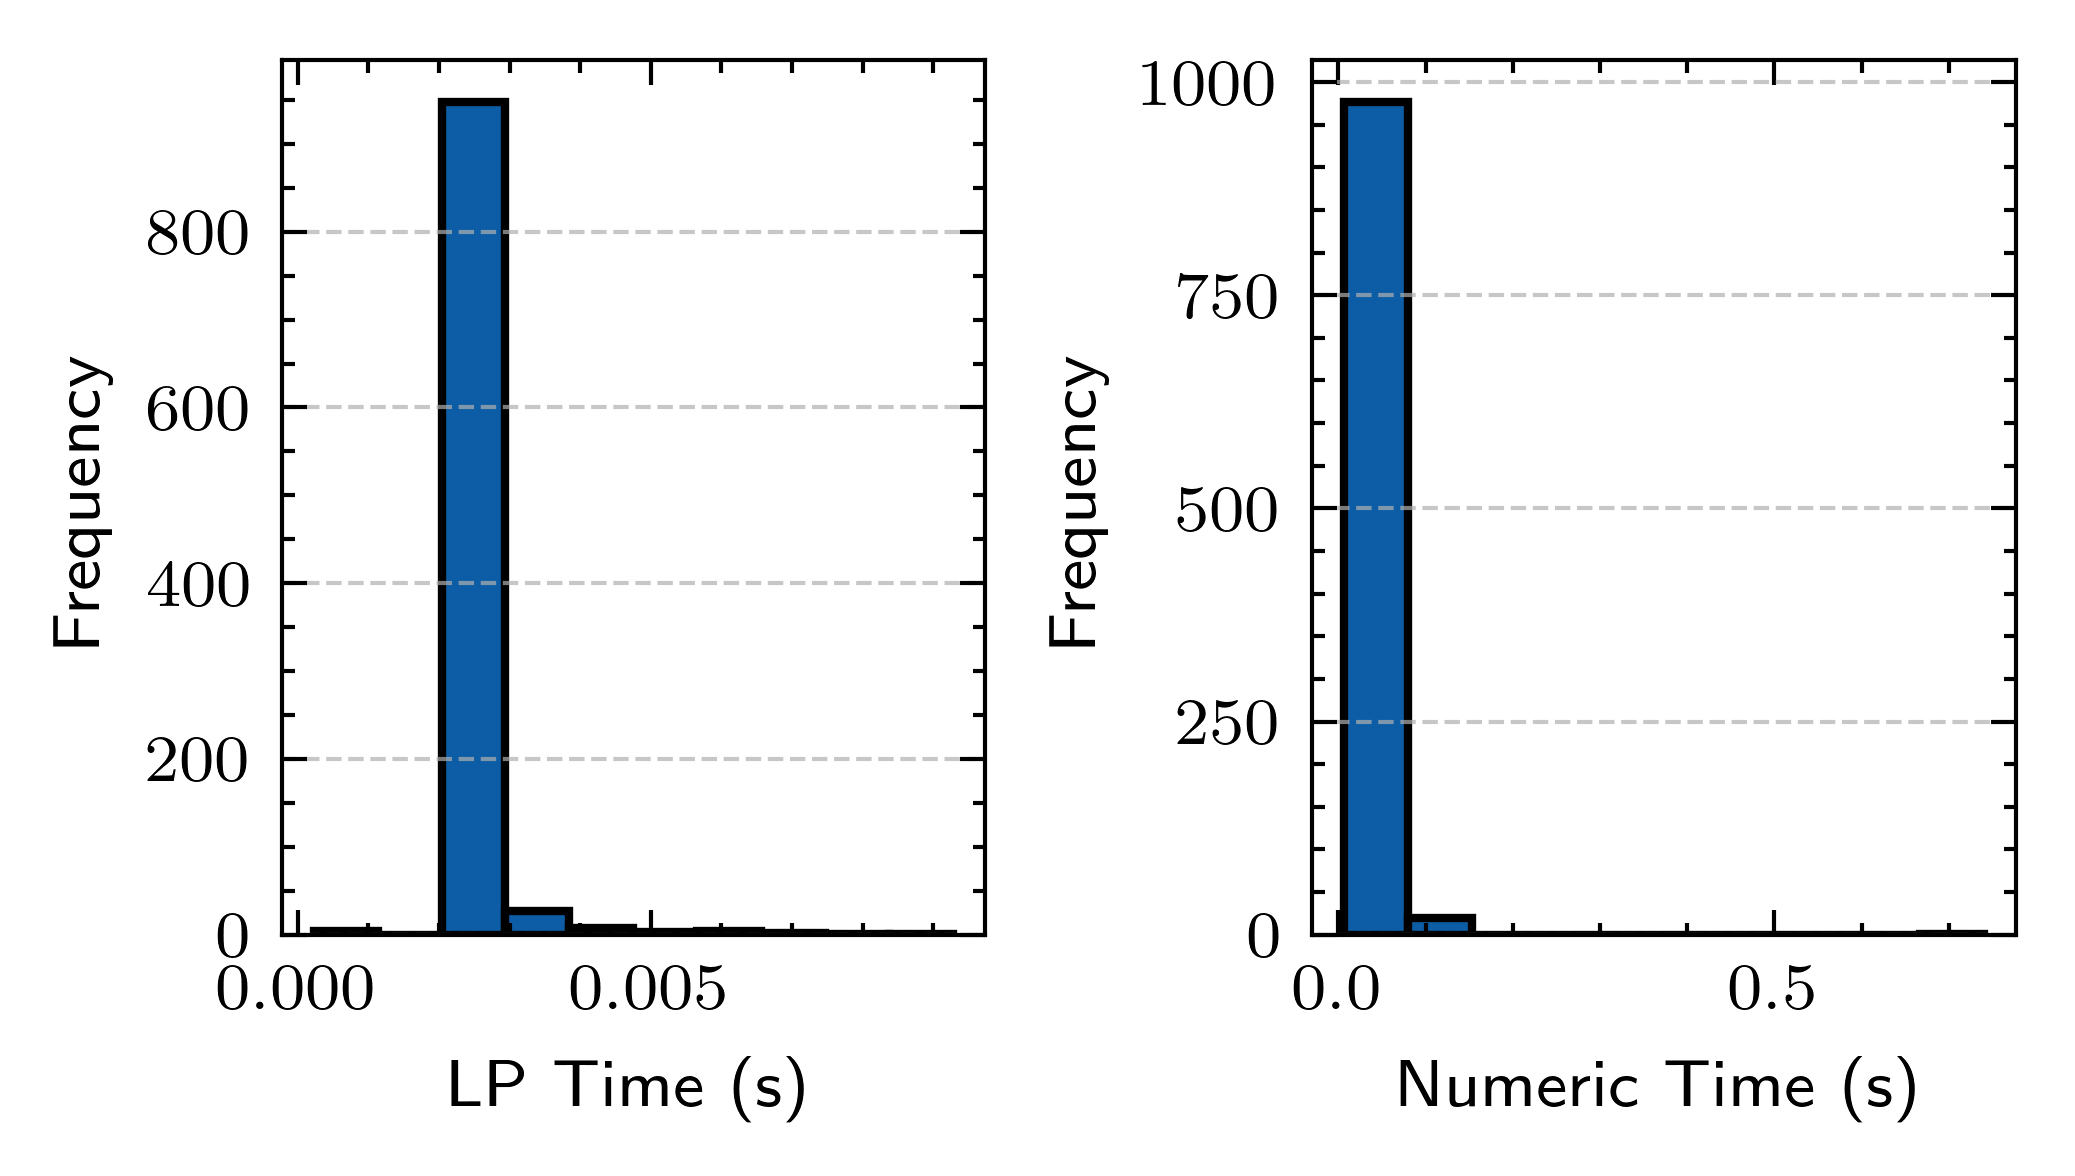

In [12]:
# Convert list of dicts to lists of values
lp_times = [d["lp_sentence"] for d in all_timings]
numeric_times = [d["segments"] for d in all_timings]

with plt.style.context(["ieee", "science", "use_mathtext"]):
    fig, axes = plt.subplots(1, 2, figsize=(3.5, 2))

    axes[0].set_xlabel("LP Time (s)")
    axes[0].set_ylabel("Frequency")
    axes[0].grid(axis="y", linestyle="--", alpha=0.7)
    axes[0].hist(lp_times, edgecolor="black")

    axes[1].set_xlabel("Numeric Time (s)")
    axes[1].set_ylabel("Frequency")
    axes[1].grid(axis="y", linestyle="--", alpha=0.7)
    axes[1].hist(numeric_times, edgecolor="black")

    fig.tight_layout()
plt.show()

#### Inspecting the pieces

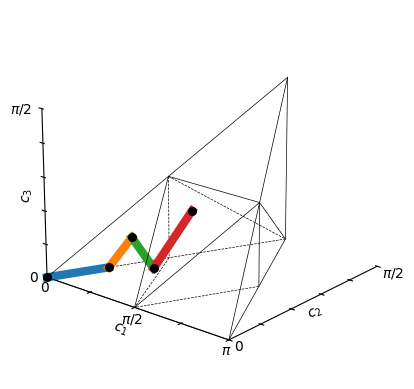

In [19]:
example_input = random_unitary(4, seed=0)
example_target = GateInvariants.from_unitary(example_input, enforce_alcove=True)
example_sentence, example_intermediates = decomposer._best_decomposition(
    target_inv=example_target
)
render_path(example_intermediates);

In [25]:
example_segment_solutions = decomposer._local_synthesis.synthesize_segments(
    example_sentence, example_intermediates, example_target
)
example_segment_solutions.draw()

global phase: 5.1451
     ┌─────────┐┌──────────┐┌─────────┐┌──────────┐┌─────────┐┌─────────┐»
q_0: ┤ Unitary ├┤0         ├┤ Unitary ├┤0         ├┤ Unitary ├┤ Unitary ├»
     ├─────────┤│  Unitary │├─────────┤│  Unitary │├─────────┤├─────────┤»
q_1: ┤ Unitary ├┤1         ├┤ Unitary ├┤1         ├┤ Unitary ├┤ Unitary ├»
     └─────────┘└──────────┘└─────────┘└──────────┘└─────────┘└─────────┘»
«     ┌──────────┐┌─────────┐┌─────────┐┌──────────┐┌─────────┐
«q_0: ┤0         ├┤ Unitary ├┤ Unitary ├┤0         ├┤ Unitary ├
«     │  Unitary │├─────────┤├─────────┤│  Unitary │├─────────┤
«q_1: ┤1         ├┤ Unitary ├┤ Unitary ├┤1         ├┤ Unitary ├
«     └──────────┘└─────────┘└─────────┘└──────────┘└─────────┘